In [415]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier


In [416]:
train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')


In [417]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [418]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [419]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [420]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [421]:
train_df.groupby(['Pclass'], as_index=False)['Survived'].mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [422]:
train_df.groupby(['Sex'], as_index=False)['Survived'].mean()

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [423]:
train_df.groupby(['SibSp'], as_index=False)['Survived'].mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [424]:
train_df.groupby(['Parch'], as_index=False)['Survived'].mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


In [425]:
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

In [426]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


In [427]:
train_df.groupby(['FamilySize'], as_index=False)['Survived'].mean()

,FamilySize,Survived
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


In [428]:
family_map = { 1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large' }
train_df['FamilySize_group'] = train_df['FamilySize'].map(family_map)
test_df['FamilySize_group'] = test_df['FamilySize'].map(family_map)

In [429]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySize_group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,Alone
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,Alone
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,Small
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,Alone


In [430]:
train_df.groupby(['FamilySize_group'], as_index=False)['Survived'].mean()

,FamilySize_group,Survived
0,Alone,0.303538
1,Large,0.160000
2,Medium,0.162162
3,Small,0.578767


In [431]:
train_df.groupby(['Embarked'], as_index=False)['Survived'].mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


In [432]:
train_df['Age_cut'] = pd.qcut(train_df['Age'], 8)
test_df['Age_cut'] = pd.qcut(test_df['Age'], 8)

In [433]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySize_group,Age_cut
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Small,"(20.125, 24.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Small,"(32.312, 38.0]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Alone,"(24.0, 28.0]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,Small,"(32.312, 38.0]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Alone,"(32.312, 38.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,Alone,"(24.0, 28.0]"
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,Alone,"(16.0, 20.125]"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,Small,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,Alone,"(24.0, 28.0]"


In [434]:
train_df.groupby(['Age_cut'], as_index=False)['Survived'].mean()

/tmp/ipykernel_10724/236160506.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Age_cut'], as_index=False)['Survived'].mean()


,Age_cut,Survived
0,"(0.419, 16.0]",0.550000
1,"(16.0, 20.125]",0.341772
2,"(20.125, 24.0]",0.367347
3,"(24.0, 28.0]",0.352941
4,"(28.0, 32.312]",0.416667
5,"(32.312, 38.0]",0.450549
6,"(38.0, 47.0]",0.329545
7,"(47.0, 80.0]",0.415730


In [435]:
train_df.loc[train_df['Age'] <= 16, 'Age'] = 0
train_df.loc[(train_df['Age'] >  16) & (train_df['Age'] <= 20.125), 'Age'] = 1
train_df.loc[(train_df['Age'] >  20.125) & (train_df['Age'] <= 24), 'Age'] = 2
train_df.loc[(train_df['Age'] >  24) & (train_df['Age'] <= 28), 'Age'] = 3
train_df.loc[(train_df['Age'] >  28) & (train_df['Age'] <= 32.312), 'Age'] = 4
train_df.loc[(train_df['Age'] >  32.312) & (train_df['Age'] <= 38), 'Age'] = 5
train_df.loc[(train_df['Age'] >  38) & (train_df['Age'] <= 47), 'Age'] = 6
train_df.loc[(train_df['Age'] >  47) & (train_df['Age'] <= 80), 'Age'] = 7
train_df.loc[train_df['Age'] >  80, 'Age'] = 8

test_df.loc[test_df['Age'] <= 16, 'Age'] = 0
test_df.loc[(test_df['Age'] >  16) & (test_df['Age'] <= 20.125), 'Age'] = 1
test_df.loc[(test_df['Age'] >  20.125) & (test_df['Age'] <= 24), 'Age'] = 2
test_df.loc[(test_df['Age'] >  24) & (test_df['Age'] <= 28), 'Age'] = 3
test_df.loc[(test_df['Age'] >  28) & (test_df['Age'] <= 32.312), 'Age'] = 4
test_df.loc[(test_df['Age'] >  32.312) & (test_df['Age'] <= 38), 'Age'] = 5
test_df.loc[(test_df['Age'] >  38) & (test_df['Age'] <= 47), 'Age'] = 6
test_df.loc[(test_df['Age'] >  47) & (test_df['Age'] <= 80), 'Age'] = 7
test_df.loc[test_df['Age'] >  80, 'Age'] = 8

In [436]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySize_group,Age_cut
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,7.2500,NaN,S,2,Small,"(20.125, 24.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,71.2833,C85,C,2,Small,"(32.312, 38.0]"
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Alone,"(24.0, 28.0]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,53.1000,C123,S,2,Small,"(32.312, 38.0]"
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,8.0500,NaN,S,1,Alone,"(32.312, 38.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,3.0,0,0,211536,13.0000,NaN,S,1,Alone,"(24.0, 28.0]"
887,888,1,1,"Graham, Miss. Margaret Edith",female,1.0,0,0,112053,30.0000,B42,S,1,Alone,"(16.0, 20.125]"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4,Small,NaN
889,890,1,1,"Behr, Mr. Karl Howell",male,3.0,0,0,111369,30.0000,C148,C,1,Alone,"(24.0, 28.0]"


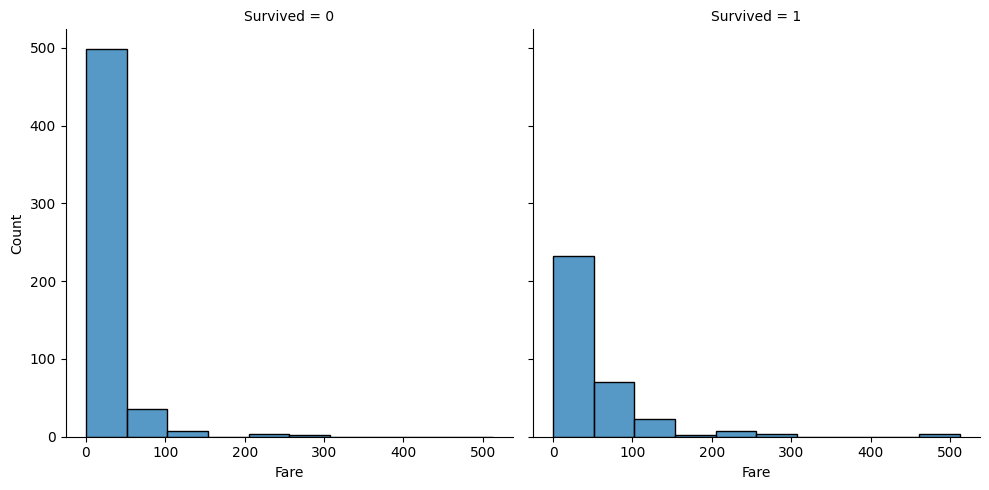

In [437]:
sns.displot(train_df,x="Fare",col="Survived",bins=10)

In [438]:
train_df.groupby(['Fare'], as_index=False)['Survived'].mean()

,Fare,Survived
0,0.0000,0.066667
1,4.0125,0.000000
2,5.0000,0.000000
3,6.2375,0.000000
4,6.4375,0.000000
...,...,...
243,227.5250,0.750000
244,247.5208,0.500000
245,262.3750,1.000000
246,263.0000,0.500000


In [439]:
train_df['Fare_cut'] = pd.qcut(train_df['Fare'], 6)
test_df['Fare_cut'] = pd.qcut(test_df['Fare'], 6)

In [440]:
train_df.groupby(['Fare_cut'], as_index=False)['Survived'].mean()

/tmp/ipykernel_10724/3412529244.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Fare_cut'], as_index=False)['Survived'].mean()


,Fare_cut,Survived
0,"(-0.001, 7.775]",0.205128
1,"(7.775, 8.662]",0.190789
2,"(8.662, 14.454]",0.366906
3,"(14.454, 26.0]",0.436242
4,"(26.0, 52.369]",0.417808
5,"(52.369, 512.329]",0.697987


In [441]:
train_df.loc[train_df['Fare'] <= 7.775, 'Fare'] = 0
train_df.loc[(train_df['Fare'] >  7.775) & (train_df['Fare'] <= 8.662), 'Fare'] = 1
train_df.loc[(train_df['Fare'] >  8.662) & (train_df['Fare'] <= 14.454), 'Fare'] = 2
train_df.loc[(train_df['Fare'] >  14.454) & (train_df['Fare'] <= 26), 'Fare'] = 3
train_df.loc[(train_df['Fare'] >  26) & (train_df['Fare'] <= 52.369), 'Fare'] = 4
train_df.loc[(train_df['Fare'] >  52.369) & (train_df['Fare'] <= 512.329), 'Fare'] = 5
train_df.loc[train_df['Fare'] >  512.329, 'Fare'] = 6

test_df.loc[test_df['Fare'] <= 7.775, 'Fare'] = 0
test_df.loc[(test_df['Fare'] >  7.775) & (test_df['Fare'] <= 8.662), 'Fare'] = 1
test_df.loc[(test_df['Fare'] >  8.662) & (test_df['Fare'] <= 14.454), 'Fare'] = 2
test_df.loc[(test_df['Fare'] >  14.454) & (test_df['Fare'] <= 26), 'Fare'] = 3
test_df.loc[(test_df['Fare'] >  26) & (test_df['Fare'] <= 52.369), 'Fare'] = 4
test_df.loc[(test_df['Fare'] >  52.369) & (test_df['Fare'] <= 512.329), 'Fare'] = 5
test_df.loc[test_df['Fare'] >  512.329, 'Fare'] = 6

In [442]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySize_group,Age_cut,Fare_cut
0,892,3,"Kelly, Mr. James",male,5.0,0,0,330911,1.0,NaN,Q,1,Alone,"(32.0, 39.0]","(7.758, 8.662]"
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,6.0,1,0,363272,0.0,NaN,S,2,Small,"(39.0, 48.0]","(-0.001, 7.758]"
2,894,2,"Myles, Mr. Thomas Francis",male,7.0,0,0,240276,2.0,NaN,Q,1,Alone,"(48.0, 76.0]","(8.662, 14.454]"
3,895,3,"Wirz, Mr. Albert",male,3.0,0,0,315154,2.0,NaN,S,1,Alone,"(24.0, 27.0]","(7.758, 8.662]"
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,2.0,1,1,3101298,2.0,NaN,S,3,Small,"(21.0, 24.0]","(8.662, 14.454]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,1.0,NaN,S,1,Alone,NaN,"(7.758, 8.662]"
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,6.0,0,0,PC 17758,5.0,C105,C,1,Alone,"(32.0, 39.0]","(56.144, 512.329]"
415,1307,3,"Saether, Mr. Simon Sivertsen",male,6.0,0,0,SOTON/O.Q. 3101262,0.0,NaN,S,1,Alone,"(32.0, 39.0]","(-0.001, 7.758]"
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,1.0,NaN,S,1,Alone,NaN,"(7.758, 8.662]"


In [443]:
train_df['Title'] = train_df['Name'].str.split(',',expand=True)[1].str.split('.',expand=True)[0].apply(lambda x: x.strip())
test_df['Title'] = test_df['Name'].str.split(',',expand=True)[1].str.split('.',expand=True)[0].apply(lambda x: x.strip())

In [444]:
train_df.groupby(['Title'], as_index=False)['Survived'].agg(['mean','count'])

,Title,mean,count
0,Capt,0.000000,1
1,Col,0.500000,2
2,Don,0.000000,1
3,Dr,0.428571,7
4,Jonkheer,0.000000,1
5,Lady,1.000000,1
6,Major,0.500000,2
7,Master,0.575000,40
8,Miss,0.697802,182
9,Mlle,1.000000,2


In [445]:
#military: Capt, Col , Major
#noble : Don, Lady, Sir, Jonkheer, the Countess
#unmarried female: Ms, Mlle, Mme

train_df['Title'] = train_df['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Don': 'Noble',
    'Lady': 'Noble',
    'Sir': 'Noble',
    'Jonkheer': 'Noble',
    'the Countess': 'Noble',
    'Ms': 'Noble',
    'Mlle': 'Noble',
    'Mme': 'Noble',
})

test_df['Title'] = test_df['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Don': 'Noble',
    'Lady': 'Noble',
    'Sir': 'Noble',
    'Jonkheer': 'Noble',
    'the Countess': 'Noble',
    'Ms': 'Noble',
    'Mlle': 'Noble',
    'Mme': 'Noble',
})

In [446]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySize_group,Age_cut,Fare_cut,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,2,Small,"(20.125, 24.0]","(-0.001, 7.775]",Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,2,Small,"(32.312, 38.0]","(52.369, 512.329]",Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,1,Alone,"(24.0, 28.0]","(7.775, 8.662]",Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,2,Small,"(32.312, 38.0]","(52.369, 512.329]",Mrs
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,1,Alone,"(32.312, 38.0]","(7.775, 8.662]",Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,3.0,0,0,211536,2.0,NaN,S,1,Alone,"(24.0, 28.0]","(8.662, 14.454]",Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,1.0,0,0,112053,4.0,B42,S,1,Alone,"(16.0, 20.125]","(26.0, 52.369]",Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,3.0,NaN,S,4,Small,NaN,"(14.454, 26.0]",Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,3.0,0,0,111369,4.0,C148,C,1,Alone,"(24.0, 28.0]","(26.0, 52.369]",Mr


In [447]:
train_df.groupby(['Title'], as_index=False)['Survived'].agg(['mean','count'])

,Title,mean,count
0,Dr,0.428571,7
1,Master,0.575000,40
2,Military,0.400000,5
3,Miss,0.697802,182
4,Mr,0.156673,517
5,Mrs,0.792000,125
6,Noble,0.777778,9
7,Rev,0.000000,6


In [448]:
train_df['Name_length'] = train_df['Name'].apply(lambda x: len(x))
test_df['Name_length'] = test_df['Name'].apply(lambda x: len(x))

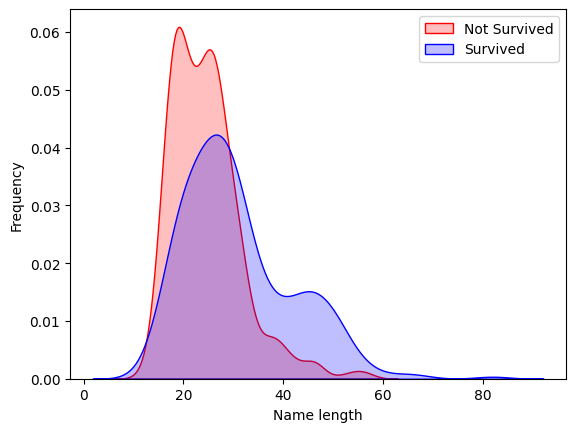

In [449]:
g = sns.kdeplot(train_df['Name_length'][(train_df['Survived']==0)&(train_df['Name_length'].notnull())], color='red', fill=True)
g = sns.kdeplot(train_df['Name_length'][(train_df['Survived']==1)&(train_df['Name_length'].notnull())],ax=g, color='blue', fill=True)
g.set_xlabel('Name length')
g.set_ylabel('Frequency')
g = g.legend(['Not Survived', 'Survived'])

In [450]:
train_df['Name_lengthGB'] = pd.qcut(train_df['Name_length'], 8)
test_df['Name_lengthGB'] = pd.qcut(train_df['Name_length'], 8)

In [451]:
train_df.groupby(['Name_lengthGB'], as_index=False)['Survived'].agg(['mean','count'])

/tmp/ipykernel_10724/2218661734.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(['Name_lengthGB'], as_index=False)['Survived'].agg(['mean','count'])


,Name_lengthGB,mean,count
0,"(11.999, 18.0]",0.214286,140
1,"(18.0, 20.0]",0.252427,103
2,"(20.0, 23.0]",0.307692,117
3,"(23.0, 25.0]",0.346939,98
4,"(25.0, 27.25]",0.292929,99
5,"(27.25, 30.0]",0.428571,112
6,"(30.0, 38.0]",0.517241,116
7,"(38.0, 82.0]",0.745283,106


In [452]:
train_df.loc[train_df['Name_length'] <= 18, 'Name_Size'] = 0
train_df.loc[(train_df['Name_length'] >  18) & (train_df['Name_length'] <= 20), 'Name_Size'] = 1
train_df.loc[(train_df['Name_length'] >  20) & (train_df['Name_length'] <= 23), 'Name_Size'] = 2
train_df.loc[(train_df['Name_length'] >  23) & (train_df['Name_length'] <= 25), 'Name_Size'] = 3
train_df.loc[(train_df['Name_length'] >  25) & (train_df['Name_length'] <= 27.25), 'Name_Size'] = 4
train_df.loc[(train_df['Name_length'] >  27.25) & (train_df['Name_length'] <= 30), 'Name_Size'] = 5
train_df.loc[(train_df['Name_length'] >  30) & (train_df['Name_length'] <= 38), 'Name_Size'] = 6
train_df.loc[(train_df['Name_length'] >  38) & (train_df['Name_length'] <= 82), 'Name_Size'] = 7
train_df.loc[train_df['Name_length'] >  82, 'Name_Size'] = 8

test_df.loc[test_df['Name_length'] <= 18, 'Name_Size'] = 0
test_df.loc[(test_df['Name_length'] >  18) & (test_df['Name_length'] <= 20), 'Name_Size'] = 1
test_df.loc[(test_df['Name_length'] >  20) & (test_df['Name_length'] <= 23), 'Name_Size'] = 2
test_df.loc[(test_df['Name_length'] >  23) & (test_df['Name_length'] <= 25), 'Name_Size'] = 3
test_df.loc[(test_df['Name_length'] >  25) & (test_df['Name_length'] <= 27.25), 'Name_Size'] = 4
test_df.loc[(test_df['Name_length'] >  27.25) & (test_df['Name_length'] <= 30), 'Name_Size'] = 5
test_df.loc[(test_df['Name_length'] >  30) & (test_df['Name_length'] <= 38), 'Name_Size'] = 6
test_df.loc[(test_df['Name_length'] >  38) & (test_df['Name_length'] <= 82), 'Name_Size'] = 7
test_df.loc[test_df['Name_length'] >  82, 'Name_Size'] = 8

In [453]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySize_group,Age_cut,Fare_cut,Title,Name_length,Name_lengthGB,Name_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,2,Small,"(20.125, 24.0]","(-0.001, 7.775]",Mr,23,"(20.0, 23.0]",2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,2,Small,"(32.312, 38.0]","(52.369, 512.329]",Mrs,51,"(38.0, 82.0]",7.0
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,1,Alone,"(24.0, 28.0]","(7.775, 8.662]",Miss,22,"(20.0, 23.0]",2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,2,Small,"(32.312, 38.0]","(52.369, 512.329]",Mrs,44,"(38.0, 82.0]",7.0
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,1,Alone,"(32.312, 38.0]","(7.775, 8.662]",Mr,24,"(23.0, 25.0]",3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,3.0,0,0,211536,2.0,NaN,S,1,Alone,"(24.0, 28.0]","(8.662, 14.454]",Rev,21,"(20.0, 23.0]",2.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,1.0,0,0,112053,4.0,B42,S,1,Alone,"(16.0, 20.125]","(26.0, 52.369]",Miss,28,"(27.25, 30.0]",5.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,3.0,NaN,S,4,Small,NaN,"(14.454, 26.0]",Miss,40,"(38.0, 82.0]",7.0
889,890,1,1,"Behr, Mr. Karl Howell",male,3.0,0,0,111369,4.0,C148,C,1,Alone,"(24.0, 28.0]","(26.0, 52.369]",Mr,21,"(20.0, 23.0]",2.0


In [454]:
train_df['Ticket']

0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: object

In [455]:
train_df['TicketNumber'] = train_df['Ticket'].apply(lambda x: pd.Series({'Ticket': x.split()[-1]}))
test_df['TicketNumber'] = test_df['Ticket'].apply(lambda x: pd.Series({'Ticket': x.split()[-1]}))

In [456]:
train_df.groupby(['TicketNumber'], as_index=False)['Survived'].agg(['mean','count']).sort_values(by='count', ascending=False)   

,TicketNumber,mean,count
94,1601,0.714286,7
196,2343,0.000000,7
464,347082,0.000000,7
468,347088,0.000000,6
358,3101295,0.000000,6
...,...,...,...
276,2667,1.000000,1
278,2669,0.000000,1
279,26707,0.000000,1
280,2671,0.000000,1


In [457]:
train_df['TicketNumberCounts'] = train_df.groupby(['TicketNumber'])['TicketNumber'].transform('count')
test_df['TicketNumberCounts'] = test_df.groupby(['TicketNumber'])['TicketNumber'].transform('count')

In [458]:
train_df.groupby(['TicketNumberCounts'], as_index=False)['Survived'].agg(['mean','count']).sort_values(by='count', ascending=False)   

,TicketNumberCounts,mean,count
0,1,0.295956,544
1,2,0.569149,188
2,3,0.712121,66
3,4,0.500000,44
6,7,0.238095,21
5,6,0.000000,18
4,5,0.000000,10


In [459]:
train_df['Ticket'].str.split(pat=' ',expand=True)[0]

0           A/5
1            PC
2      STON/O2.
3        113803
4        373450
         ...   
886      211536
887      112053
888       W./C.
889      111369
890      370376
Name: 0, Length: 891, dtype: object

In [460]:
train_df['TicketLocation'] = np.where(train_df['Ticket'].str.split(pat=' ',expand=True)[1].notna(), train_df['Ticket'].str.split(pat=' ',expand=True)[0].apply(lambda x: x.strip()), 'Blank')
test_df['TicketLocation'] = np.where(test_df['Ticket'].str.split(pat=' ',expand=True)[1].notna(), test_df['Ticket'].str.split(pat=' ',expand=True)[0].apply(lambda x: x.strip()), 'Blank')

In [461]:
train_df['TicketLocation'].value_counts()

TicketLocation
Blank         665
PC             60
C.A.           27
STON/O         12
A/5            10
W./C.           9
CA.             8
SOTON/O.Q.      8
A/5.            7
SOTON/OQ        7
STON/O2.        6
CA              6
C               5
S.O.C.          5
SC/PARIS        5
F.C.C.          5
SC/Paris        4
A/4.            3
PP              3
A/4             3
S.O./P.P.       3
SC/AH           3
A./5.           2
P/PP            2
A.5.            2
WE/P            2
SOTON/O2        2
S.C./PARIS      2
S.C./A.4.       1
Fa              1
S.O.P.          1
SO/C            1
S.P.            1
A4.             1
W.E.P.          1
A/S             1
SC              1
SW/PP           1
SCO/W           1
W/C             1
S.W./PP         1
F.C.            1
C.A./SOTON      1
Name: count, dtype: int64

In [462]:
train_df['TicketLocation'] = train_df['TicketLocation'].replace({
    'SOTON/O.Q.':'SOTON/OQ',
    'C.A.':'CA',
    'CA.':'CA',
    'SC/PARIS':'SC/Paris',
    'S.C./PARIS':'SC/Paris',
    'A/4.':'A/4',
    'A/5.':'A/5',
    'A.5.':'A/5',
    'A./5.':'A/5',
    'W./C.':'W/C',
})
test_df['TicketLocation'] = test_df['TicketLocation'].replace({
    'SOTON/O.Q.':'SOTON/OQ',
    'C.A.':'CA',
    'CA.':'CA',
    'SC/PARIS':'SC/Paris',
    'S.C./PARIS':'SC/Paris',
    'A/4.':'A/4',
    'A/5.':'A/5',
    'A.5.':'A/5',
    'A./5.':'A/5',
    'W./C.':'W/C',
})

In [463]:
train_df.groupby(['TicketLocation'], as_index=False)['Survived'].agg(['mean','count'])

,TicketLocation,mean,count
0,A/4,0.000000,6
1,A/5,0.095238,21
2,A/S,0.000000,1
3,A4.,0.000000,1
4,Blank,0.383459,665
5,C,0.400000,5
6,C.A./SOTON,0.000000,1
7,CA,0.341463,41
8,F.C.,0.000000,1
9,F.C.C.,0.800000,5


In [464]:
train_df['Cabin'] = train_df['Cabin'].fillna('U')
train_df['Cabin'] = pd.Series([i[0] if not  pd.isnull(i) else 'x'for i in train_df['Cabin']])

test_df['Cabin'] = test_df['Cabin'].fillna('U')
test_df['Cabin'] = pd.Series([i[0] if not  pd.isnull(i) else 'x'for i in test_df['Cabin']])


In [465]:
train_df.groupby(['Cabin'], as_index=False)['Survived'].agg(['mean','count'])

,Cabin,mean,count
0,A,0.466667,15
1,B,0.744681,47
2,C,0.593220,59
3,D,0.757576,33
4,E,0.750000,32
5,F,0.615385,13
6,G,0.500000,4
7,T,0.000000,1
8,U,0.299854,687


In [466]:
train_df['Cabin_Assigned'] = train_df['Cabin'].apply(lambda x: 0 if x in ['U'] else 1)
test_df['Cabin_Assigned'] = test_df['Cabin'].apply(lambda x: 0 if x in ['U'] else 1)

In [467]:
train_df.groupby(['Cabin_Assigned'], as_index=False)['Survived'].agg(['mean','count'])

,Cabin_Assigned,mean,count
0,0,0.299854,687
1,1,0.666667,204


In [468]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Age_cut,Fare_cut,Title,Name_length,Name_lengthGB,Name_Size,TicketNumber,TicketNumberCounts,TicketLocation,Cabin_Assigned
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,...,"(20.125, 24.0]","(-0.001, 7.775]",Mr,23,"(20.0, 23.0]",2.0,21171,1,A/5,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,...,"(32.312, 38.0]","(52.369, 512.329]",Mrs,51,"(38.0, 82.0]",7.0,17599,1,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,...,"(24.0, 28.0]","(7.775, 8.662]",Miss,22,"(20.0, 23.0]",2.0,3101282,1,STON/O2.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,...,"(32.312, 38.0]","(52.369, 512.329]",Mrs,44,"(38.0, 82.0]",7.0,113803,2,Blank,1
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,...,"(32.312, 38.0]","(7.775, 8.662]",Mr,24,"(23.0, 25.0]",3.0,373450,1,Blank,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,3.0,0,0,211536,2.0,...,"(24.0, 28.0]","(8.662, 14.454]",Rev,21,"(20.0, 23.0]",2.0,211536,1,Blank,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,1.0,0,0,112053,4.0,...,"(16.0, 20.125]","(26.0, 52.369]",Miss,28,"(27.25, 30.0]",5.0,112053,1,Blank,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,3.0,...,NaN,"(14.454, 26.0]",Miss,40,"(38.0, 82.0]",7.0,6607,2,W/C,0
889,890,1,1,"Behr, Mr. Karl Howell",male,3.0,0,0,111369,4.0,...,"(24.0, 28.0]","(26.0, 52.369]",Mr,21,"(20.0, 23.0]",2.0,111369,1,Blank,1


In [469]:
train_df.shape

(891, 24)

In [470]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Age_cut,Fare_cut,Title,Name_length,Name_lengthGB,Name_Size,TicketNumber,TicketNumberCounts,TicketLocation,Cabin_Assigned
0,892,3,"Kelly, Mr. James",male,5.0,0,0,330911,1.0,U,...,"(32.0, 39.0]","(7.758, 8.662]",Mr,16,"(20.0, 23.0]",0.0,330911,1,Blank,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,6.0,1,0,363272,0.0,U,...,"(39.0, 48.0]","(-0.001, 7.758]",Mrs,32,"(38.0, 82.0]",6.0,363272,1,Blank,0
2,894,2,"Myles, Mr. Thomas Francis",male,7.0,0,0,240276,2.0,U,...,"(48.0, 76.0]","(8.662, 14.454]",Mr,25,"(20.0, 23.0]",3.0,240276,1,Blank,0
3,895,3,"Wirz, Mr. Albert",male,3.0,0,0,315154,2.0,U,...,"(24.0, 27.0]","(7.758, 8.662]",Mr,16,"(38.0, 82.0]",0.0,315154,1,Blank,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,2.0,1,1,3101298,2.0,U,...,"(21.0, 24.0]","(8.662, 14.454]",Mrs,44,"(23.0, 25.0]",7.0,3101298,1,Blank,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,1.0,U,...,NaN,"(7.758, 8.662]",Mr,18,"(27.25, 30.0]",0.0,3236,1,A/5,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,6.0,0,0,PC 17758,5.0,C,...,"(32.0, 39.0]","(56.144, 512.329]",Dona,28,"(23.0, 25.0]",5.0,17758,1,PC,1
415,1307,3,"Saether, Mr. Simon Sivertsen",male,6.0,0,0,SOTON/O.Q. 3101262,0.0,U,...,"(32.0, 39.0]","(-0.001, 7.758]",Mr,28,"(38.0, 82.0]",5.0,3101262,1,SOTON/OQ,0
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,1.0,U,...,NaN,"(7.758, 8.662]",Mr,19,"(38.0, 82.0]",1.0,359309,1,Blank,0


In [471]:
test_df.shape

(418, 23)

In [472]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   PassengerId         891 non-null    int64   
 1   Survived            891 non-null    int64   
 2   Pclass              891 non-null    int64   
 3   Name                891 non-null    object  
 4   Sex                 891 non-null    object  
 5   Age                 714 non-null    float64 
 6   SibSp               891 non-null    int64   
 7   Parch               891 non-null    int64   
 8   Ticket              891 non-null    object  
 9   Fare                891 non-null    float64 
 10  Cabin               891 non-null    object  
 11  Embarked            889 non-null    object  
 12  FamilySize          891 non-null    int64   
 13  FamilySize_group    891 non-null    object  
 14  Age_cut             714 non-null    category
 15  Fare_cut            891 non-null    cate

In [473]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize',
       'FamilySize_group', 'Age_cut', 'Fare_cut', 'Title', 'Name_length',
       'Name_lengthGB', 'Name_Size', 'TicketNumber', 'TicketNumberCounts',
       'TicketLocation', 'Cabin_Assigned'],
      dtype='object')

In [474]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   PassengerId         418 non-null    int64   
 1   Pclass              418 non-null    int64   
 2   Name                418 non-null    object  
 3   Sex                 418 non-null    object  
 4   Age                 332 non-null    float64 
 5   SibSp               418 non-null    int64   
 6   Parch               418 non-null    int64   
 7   Ticket              418 non-null    object  
 8   Fare                417 non-null    float64 
 9   Cabin               418 non-null    object  
 10  Embarked            418 non-null    object  
 11  FamilySize          418 non-null    int64   
 12  FamilySize_group    418 non-null    object  
 13  Age_cut             332 non-null    category
 14  Fare_cut            417 non-null    category
 15  Title               418 non-null    obje

In [475]:
train_df.groupby(['Age'], as_index=False)['Survived'].agg(['mean','count'])

,Age,mean,count
0,0.0,0.550000,100
1,1.0,0.341772,79
2,2.0,0.367347,98
3,3.0,0.352941,85
4,4.0,0.416667,84
5,5.0,0.450549,91
6,6.0,0.329545,88
7,7.0,0.415730,89


In [476]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].mean())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].mean())

test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].mean())


In [477]:
ohe = OneHotEncoder(sparse_output=False)
ode = OrdinalEncoder()
SI = SimpleImputer(strategy='most_frequent')

In [478]:
ode_cols = ['FamilySize_group']
ohe_cols = ['Sex','Embarked']

In [479]:
X = train_df.drop(['Survived'], axis=1)
y = train_df['Survived']

X_test = test_df.drop(['Age_cut','Fare_cut'], axis=1)

In [480]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

In [481]:
ordinal_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [482]:
ohe_pipeline = Pipeline(steps=[
    ('imputr', SimpleImputer(strategy='most_frequent')),
    ('one-hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [483]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'FamilySize_group',
       'Age_cut', 'Fare_cut', 'Title', 'Name_length', 'Name_lengthGB',
       'Name_Size', 'TicketNumber', 'TicketNumberCounts', 'TicketLocation',
       'Cabin_Assigned'],
      dtype='object')

In [484]:
col_trans = ColumnTransformer(transformers=[
    ('impute', SI , ['Age']),
    ('ord_pipeline', ordinal_pipeline, ode_cols),
    ('ohe_pipeline', ohe_pipeline, ohe_cols),
    ('passthrough', 'passthrough', ['Pclass','TicketNumberCounts','Cabin_Assigned','Name_Size','Age','Fare'])
    ],
    remainder='drop',
    n_jobs=-1
)

In [485]:
rfc = RandomForestClassifier()

In [486]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'min_samples_split': [5, 10, 15],
    'max_depth': [8, 9, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

In [487]:
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [488]:
pipefinalrfc = make_pipeline(col_trans, CV_rfc)
pipefinalrfc.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['FamilySize_group']),
                                                 ('ohe_pipeline',
                                                  Pipeline(step...
                                                  ['Pclass',
                                                   'TicketNumberCounts',
                                                   'Cabin_Assigned',
                                                   'Name_Size', 'Age',
                                                   'Fare'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=RandomForestClassifier(),
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [8, 9, 10],
                                          'min_samples_leaf': [1, 2, 4],
                                          'min_samples_split': [5, 10, 15],
                                          'n_estimators': [100, 150, 200]}))])

In [489]:
print(CV_rfc.best_params_)
print(CV_rfc.best_score_)

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
0.8385304836009061


In [490]:
dtc = DecisionTreeClassifier()

In [491]:
param_grid = {
    'min_samples_split': [5, 10, 15],
    'max_depth': [10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

In [492]:
CV_dtc = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [493]:
pipefinaldtc = make_pipeline(col_trans, CV_dtc)
pipefinaldtc.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['FamilySize_group']),
                                                 ('ohe_pipeline',
                                                  Pipeline(step...
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass',
                                                   'TicketNumberCounts',
                                                   'Cabin_Assigned',
                                                   'Name_Size', 'Age',
                                                   'Fare'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=DecisionTreeClassifier(),
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [10, 20, 30],
                                          'min_samples_leaf': [1, 2, 4],
                                          'min_samples_split': [5, 10, 15]}))])

In [494]:
print(CV_dtc.best_params_)
print(CV_dtc.best_score_)

{'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 4, 'min_samples_split': 15}
0.8132374667585935


In [495]:
knn = KNeighborsClassifier()

In [496]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p':[1,2],
}

In [497]:
CV_knn = GridSearchCV(estimator=knn, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [498]:
pipefinalknn = make_pipeline(col_trans, CV_knn)
pipefinalknn.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['FamilySize_group']),
                                                 ('ohe_pipeline',
                                                  Pipeline(step...
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass',
                                                   'TicketNumberCounts',
                                                   'Cabin_Assigned',
                                                   'Name_Size', 'Age',
                                                   'Fare'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=KNeighborsClassifier(),
                              param_grid={'algorithm': ['auto', 'ball_tree',
                                                        'kd_tree', 'brute'],
                                          'n_neighbors': [3, 5, 7, 9, 11],
                                          'p': [1, 2],
                                          'weights': ['uniform',
                                                      'distance']}))])

In [499]:
print(CV_knn.best_params_)
print(CV_knn.best_score_)

{'algorithm': 'auto', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
0.8076824583866837


In [500]:
svc = SVC()

In [501]:
param_grid = {
    'C' : [100, 10, 1, 0.1, 0.01, 0.001],
    'kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
}

In [502]:
CV_svc = GridSearchCV(estimator=svc, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [503]:
pipefinalsvc = make_pipeline(col_trans, CV_svc)
pipefinalsvc.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['FamilySize_group']),
                                                 ('ohe_pipeline',
                                                  Pipeline(step...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked']),
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass',
                                                   'TicketNumberCounts',
                                                   'Cabin_Assigned',
                                                   'Name_Size', 'Age',
                                                   'Fare'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=SVC(),
                              param_grid={'C': [100, 10, 1, 0.1, 0.01, 0.001],
                                          'kernel': ['linear', 'poly', 'rbf',
                                                     'sigmoid']}))])

In [504]:
print(CV_svc.best_params_)
print(CV_svc.best_score_)

{'C': 10, 'kernel': 'rbf'}
0.8202501723628485


In [505]:
lr = LogisticRegression()

In [506]:
param_grid = {
    'C' : [100, 10, 1, 0.1, 0.01, 0.001],
}

In [507]:
CV_lr = GridSearchCV(estimator=lr, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [508]:
pipefinallr = make_pipeline(col_trans, CV_lr)
pipefinallr.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['FamilySize_group']),
                                                 ('ohe_pipeline',
                                                  Pipeline(step...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked']),
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass',
                                                   'TicketNumberCounts',
                                                   'Cabin_Assigned',
                                                   'Name_Size', 'Age',
                                                   'Fare'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=LogisticRegression(),
                              param_grid={'C': [100, 10, 1, 0.1, 0.01,
                                                0.001]}))])

In [509]:
print(CV_lr.best_params_)
print(CV_lr.best_score_)

{'C': 0.1}
0.8005909583374372


In [510]:
gnb = GaussianNB()

In [511]:
param_grid = {
    'var_smoothing' : [0.00000001, 0.000000001, 0.00000001],
}

In [512]:
CV_gnb = GridSearchCV(estimator=gnb, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [513]:
pipefinalgnb = make_pipeline(col_trans, CV_gnb)
pipefinalgnb.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['FamilySize_group']),
                                                 ('ohe_pipeline',
                                                  Pipeline(step...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'Embarked']),
                                                 ('passthrough', 'passthrough',
                                                  ['Pclass',
                                                   'TicketNumberCounts',
                                                   'Cabin_Assigned',
                                                   'Name_Size', 'Age',
                                                   'Fare'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=GaussianNB(),
                              param_grid={'var_smoothing': [1e-08, 1e-09,
                                                            1e-08]}))])

In [514]:
print(CV_gnb.best_params_)
print(CV_gnb.best_score_)

{'var_smoothing': 1e-08}
0.7823401950162513


In [515]:
xg = XGBClassifier()

In [516]:
param_grid = {
     'booster': ['gbtree', 'gblinear','dart'],
}

In [517]:
CV_xg = GridSearchCV(estimator=xg, param_grid=param_grid, cv=StratifiedKFold(n_splits=5))

In [518]:
pipefinalxg= make_pipeline(col_trans, CV_xg)
pipefinalxg.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('impute',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['Age']),
                                                 ('ord_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['FamilySize_group']),
                                                 ('ohe_pipeline',
                                                  Pipeline(step...
                                                      interaction_constraints=None,
                                                      learning_rate=None,
                                                      max_bin=None,
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...),
                              param_grid={'booster': ['gbtree', 'gblinear',
                                                      'dart']}))])

In [519]:
print(CV_xg.best_params_)
print(CV_xg.best_score_)

{'booster': 'gbtree'}
0.799162809021964


In [520]:
Y_pred = pipefinalrfc.predict(X_test)
Y_pred2 = pipefinaldtc.predict(X_test)
Y_pred3 = pipefinalknn.predict(X_test)
Y_pred4 = pipefinalsvc.predict(X_test)
Y_pred5 = pipefinallr.predict(X_test)
Y_pred6 = pipefinalgnb.predict(X_test)
Y_pred7 = pipefinalxg.predict(X_test)

In [521]:
submission1 = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": Y_pred
})
submission2 = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": Y_pred2
})
submission3 = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": Y_pred3
})
submission4 = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": Y_pred4
})
submission5 = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": Y_pred5
})
submission6 = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": Y_pred6
})
submission7 = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": Y_pred7
})

In [522]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [523]:
test_df['PassengerId']

0       892
1       893
2       894
3       895
4       896
       ... 
413    1305
414    1306
415    1307
416    1308
417    1309
Name: PassengerId, Length: 418, dtype: int64

In [524]:
submission1.to_csv('submissions/submission0105_1.csv', index=False)
submission2.to_csv('submissions/submission0105_2.csv', index=False)
submission3.to_csv('submissions/submission0105_3.csv', index=False)
submission4.to_csv('submissions/submission0105_4.csv', index=False)
submission5.to_csv('submissions/submission0105_5.csv', index=False)
submission6.to_csv('submissions/submission0105_6.csv', index=False)
submission7.to_csv('submissions/submission0105_7.csv', index=False)